In [1]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler # Import RandomOverSampler (ROSE)
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [3]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [5]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [6]:
df.head(5)

,V013,V024,V025,V106,V404,V714,BMI_fixed,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,7,6,2,0,0,0,46.90,0,0,0,2,2,2,1,4,2,0,1,4,1
1,4,6,1,2,0,1,46.74,1,2,0,1,1,1,2,1,2,2,1,4,0
2,5,4,1,2,0,0,45.28,1,3,1,2,2,2,4,1,2,2,1,4,1
3,7,6,1,0,0,0,45.21,1,2,0,2,2,2,2,1,2,2,1,4,0
4,4,7,2,3,0,0,45.09,0,1,0,1,1,1,1,2,1,0,1,4,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [8]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [10]:
# Robust Scaling (FT4)
from sklearn.preprocessing import RobustScaler  # import robust scaler
FT4 = RobustScaler()  # create the robust scaler
FT4_data = FT4.fit_transform(df)  # scale data using median and spread
FT4_df = pd.DataFrame(FT4_data, columns=df.columns)  # convert scaled data into a DataFrame
print(FT4_df.head())  # show the first few robust scaled rows

       V013  V024  V025  V106  V404  V714  Media_acccess  husband_education  \
0  1.000000  0.50   0.0  -2.0   0.0   0.0           -1.0               -1.0   
1  0.000000  0.50  -1.0   0.0   0.0   1.0            0.0                1.0   
2  0.333333  0.00  -1.0   0.0   0.0   0.0            0.0                2.0   
3  1.000000  0.50  -1.0  -2.0   0.0   0.0            0.0                1.0   
4  0.000000  0.75   0.0   1.0   0.0   0.0           -1.0                0.0   

   contraceptive_use  Number_of_children  Living_children  Age_of_husband  \
0               -1.0                 1.0              1.0             1.0   
1               -1.0                 0.0              0.0             0.0   
2                0.0                 1.0              1.0             1.0   
3               -1.0                 1.0              1.0             1.0   
4               -1.0                 0.0              0.0             0.0   

   profession_of_husband  Birth_Interval  Drinking_water  Weal

In [11]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [12]:
# FT4_df.head()  # this would preview the robust scaled data
y = FT4_df.BMI  # use bmi1 as the target variable
x = FT4_df.drop('BMI', axis=1)  # use the other columns as features

In [13]:
y  # display the target column

,BMI
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
8497,-1.0
8498,-1.0
8499,-1.0
8500,-1.0


In [14]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,1.000000,0.50,0.0,-2.0,0.0,0.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,-0.333333,0.333333,0.0,-0.5,0.0,1.0
1,0.000000,0.50,-1.0,0.0,0.0,1.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,-0.666667,0.0,0.5,0.0,0.0
2,0.333333,0.00,-1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1.0,0.666667,-0.666667,0.0,0.5,0.0,1.0
3,1.000000,0.50,-1.0,-2.0,0.0,0.0,0.0,1.0,-1.0,1.0,1.0,1.0,0.000000,-0.666667,0.0,0.5,0.0,0.0
4,0.000000,0.75,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,-0.333333,-0.333333,-1.0,-0.5,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,0.666667,0.25,0.0,-1.0,0.0,0.0,-1.0,-1.0,0.0,1.0,0.0,1.0,-0.333333,0.000000,0.0,-0.5,0.0,0.0
8498,0.666667,-0.25,-1.0,-2.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.333333,0.000000,-1.0,0.0,0.0,1.0
8499,0.666667,-0.50,0.0,-2.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,1.0,0.000000,-0.666667,0.0,-0.5,0.0,1.0
8500,0.000000,0.75,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.000000,-0.333333,0.0,-0.5,-1.0,1.0


In [15]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(5951, 18)

In [16]:
y_train = LabelEncoder().fit_transform(y_train)  # change target labels into numbers
oversample = RandomOverSampler(random_state=101)  # create RandomOverSampler to balance classes
x_train, y_train = oversample.fit_resample(x_train, y_train)  # make class counts more balanced
counter = Counter(y_train)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y_train) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=2, count=3110, percentage=25.000%
class=1, count=3110, percentage=25.000%
class=3, count=3110, percentage=25.000%
class=0, count=3110, percentage=25.000%


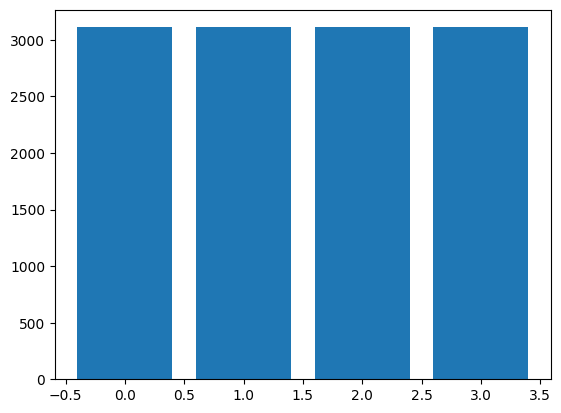

In [17]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [18]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(2551, 18)

In [19]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

=== Training Performance ===
              precision    recall  f1-score   support

           0     0.4508    0.5981    0.5141      3110
           1     0.3138    0.2148    0.2550      3110
           2     0.3495    0.2199    0.2700      3110
           3     0.4248    0.5775    0.4895      3110

    accuracy                         0.4026     12440
   macro avg     0.3847    0.4026    0.3821     12440
weighted avg     0.3847    0.4026    0.3821     12440

[[1860  569  293  388]
 [1175  668  506  761]
 [ 649  494  684 1283]
 [ 442  398  474 1796]]
=== Test Performance ===
              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6159    0.3753    0.4664      1359
         1.0     0.2755    0.1682    0.2089       755
         2.0     0.0841    0.1827    0.1152       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2638      2551
   macro avg     0.1951    0.1452    0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Cross Validation Scores are [0.54759107 0.53701528 0.54470588 0.52470588 0.53411765 0.53764706
 0.53764706 0.53058824 0.53411765 0.53882353 0.54524089 0.53231492
 0.52352941 0.53529412 0.53529412 0.54705882 0.54588235 0.55058824
 0.55647059 0.51058824 0.52878966 0.54171563 0.53058824 0.54352941
 0.53058824 0.53411765 0.52470588 0.54941176 0.54352941 0.54235294]
Average Cross Validation score :0.537284993433331


In [20]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.5610    0.1185    0.1956      1359
         1.0     0.2795    0.4609    0.3480       755
         2.0     0.0894    0.3503    0.1424       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2266      2551
   macro avg     0.1860    0.1859    0.1372      2551
weighted avg     0.3885    0.2266    0.2182      2551

[[  0  38 133  51  18]
 [  0 161 686 403 109]
 [  0  72 348 249  86]
 [  0  16  78  69  34]
 [  0   0   0   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Cross Validation Scores are [0.40305523 0.39130435 0.40235294 0.37647059 0.39294118 0.41176471
 0.40117647 0.38352941 0.38705882 0.38352941 0.41010576 0.37250294
 0.40823529 0.37411765 0.40705882 0.37882353 0.42470588 0.38
 0.38       0.37411765 0.37485311 0.40188014 0.36235294 0.37882353
 0.40470588 0.39647059 0.38588235 0.40235294 0.41882353 0.37882353]
Average Cross Validation score :0.3915939724891132


In [21]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6116    0.0545    0.1000      1359
         1.0     0.2679    0.5735    0.3652       755
         2.0     0.1089    0.3858    0.1698       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2285      2551
   macro avg     0.1977    0.2027    0.1270      2551
weighted avg     0.4135    0.2285    0.1745      2551

[[  0  19 180  37   4]
 [  0  74 905 333  47]
 [  0  26 433 252  44]
 [  0   2  98  76  21]
 [  0   0   0   0   0]]
Cross Validation Scores are [0.52878966 0.50998825 0.51647059 0.50470588 0.51529412 0.49058824
 0.50941176 0.51058824 0.50470588 0.50470588 0.50176263 0.49941246
 0.51411765 0.49411765 0.53176471 0.5        0.51294118 0.51764706
 0.51411765 0.50352941 0.52526439 0.52643948 0.50823529 0.49529412
 0.51294118 0.49882353 0.49647059 0.51764706 0.52470588 0.51058824]
Average Cross Validation score 

In [22]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.5732    0.2333    0.3316      1359
         1.0     0.2706    0.2874    0.2787       755
         2.0     0.0926    0.3553    0.1469       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2368      2551
   macro avg     0.1873    0.1752    0.1514      2551
weighted avg     0.3926    0.2368    0.2705      2551

[[  0  76  83  54  27]
 [  0 317 449 382 211]
 [  0 136 217 250 152]
 [  0  24  53  70  50]
 [  0   0   0   0   0]]
Cross Validation Scores are [0.47591069 0.46180964 0.49176471 0.48470588 0.44823529 0.48705882
 0.45294118 0.47176471 0.45411765 0.46941176 0.47943596 0.48413631
 0.46941176 0.46470588 0.48705882 0.46470588 0.46823529 0.46470588
 0.47294118 0.44588235 0.46415981 0.46298472 0.49294118 0.48
 0.46470588 0.43294118 0.46352941 0.47647059 0.46941176 0.46705882]
Average Cross Validation score :0.469

In [23]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6134    0.4099    0.4914      1359
         1.0     0.2607    0.1377    0.1802       755
         2.0     0.0693    0.1320    0.0909       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2693      2551
   macro avg     0.1887    0.1359    0.1525      2551
weighted avg     0.4093    0.2693    0.3221      2551

[[  0 132  48  24  36]
 [  0 557 227 199 376]
 [  0 193 104 126 332]
 [  0  26  20  26 125]
 [  0   0   0   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Cross Validation Scores are [0.53231492 0.52056404 0.48941176 0.48352941 0.50470588 0.51529412
 0.51411765 0.50705882 0.48235294 0.48588235 0.50411281 0.51351351
 0.47882353 0.48352941 0.52352941 0.50941176 0.50941176 0.52352941
 0.51176471 0.48235294 0.49823737 0.50058754 0.48470588 0.52
 0.51411765 0.51529412 0.47411765 0.52470588 0.52470588 0.49647059]
Average Cross Validation score :0.5042717909725583


In [24]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6124    0.4570    0.5234      1359
         1.0     0.2966    0.1033    0.1532       755
         2.0     0.0831    0.1421    0.1049       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2850      2551
   macro avg     0.1984    0.1405    0.1563      2551
weighted avg     0.4205    0.2850    0.3323      2551

[[  0 147  27  24  42]
 [  0 621 146 178 414]
 [  0 214  78 107 356]
 [  0  32  12  28 125]
 [  0   0   0   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Cross Validation Scores are [0.5346651  0.5346651  0.54588235 0.52470588 0.53411765 0.53882353
 0.53294118 0.53176471 0.53764706 0.53529412 0.5440658  0.5346651
 0.52823529 0.53058824 0.53529412 0.54       0.53529412 0.54705882
 0.55176471 0.52117647 0.53113984 0.53936545 0.53647059 0.53882353
 0.53529412 0.53176471 0.52705882 0.53882353 0.54       0.54823529]
Average Cross Validation score :0.5361875072002948


In [25]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6283    0.3370    0.4387      1359
         1.0     0.2773    0.2053    0.2359       755
         2.0     0.1064    0.2183    0.1431       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2572      2551
   macro avg     0.2024    0.1521    0.1635      2551
weighted avg     0.4250    0.2572    0.3146      2551

[[  0 117  58  26  39]
 [  0 458 324 207 370]
 [  0 137 155 128 335]
 [  0  17  22  43 115]
 [  0   0   0   0   0]]
Cross Validation Scores are [0.52761457 0.55346651 0.54117647 0.52       0.52588235 0.52705882
 0.50941176 0.53294118 0.53411765 0.54       0.54759107 0.52761457
 0.51058824 0.53176471 0.52823529 0.54235294 0.54352941 0.55058824
 0.54941176 0.50705882 0.52761457 0.52878966 0.52823529 0.53529412
 0.51882353 0.52352941 0.52588235 0.53294118 0.54941176 0.54470588]
Average Cross Validation score 

In [26]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6102    0.2892    0.3924      1359
         1.0     0.2360    0.1894    0.2101       755
         2.0     0.0949    0.2944    0.1436       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2328      2551
   macro avg     0.1882    0.1546    0.1492      2551
weighted avg     0.4023    0.2328    0.2823      2551

[[  0 106  75  36  23]
 [  0 393 363 292 311]
 [  0 133 143 225 254]
 [  0  12  25  58 102]
 [  0   0   0   0   0]]
Cross Validation Scores are [0.53701528 0.53349001 0.54823529 0.51294118 0.53411765 0.55529412
 0.52       0.54       0.52117647 0.53647059 0.54876616 0.52996475
 0.52117647 0.52352941 0.54470588 0.54352941 0.53176471 0.54117647
 0.56235294 0.51882353 0.54054054 0.5440658  0.51647059 0.53058824
 0.53882353 0.53176471 0.52235294 0.54705882 0.56352941 0.54235294]
Average Cross Validation score 

In [29]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan

# Encode y for cross-validation with XGBoost, as it expects 0-indexed integer labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded_for_xgb = le.fit_transform(y) # Use a temporary encoded y for cross_val_score

scores = cross_val_score(XGB, x, y_encoded_for_xgb, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.6139    0.1369    0.2238      1359
         1.0     0.2587    0.3947    0.3125       755
         2.0     0.1070    0.4264    0.1711       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2227      2551
   macro avg     0.1959    0.1916    0.1415      2551
weighted avg     0.4118    0.2227    0.2249      2551

[[  0  51 130  46  13]
 [  0 186 664 370 139]
 [  0  59 298 285 113]
 [  0   7  60  84  46]
 [  0   0   0   0   0]]
Cross Validation Scores are [0.50176263 0.51233843 0.5        0.46823529 0.52823529 0.51411765
 0.48352941 0.47882353 0.47882353 0.46823529 0.46650999 0.48413631
 0.49764706 0.5        0.49529412 0.51294118 0.49176471 0.49411765
 0.52705882 0.46117647 0.50293772 0.48648649 0.47411765 0.49058824
 0.49882353 0.47647059 0.47294118 0.48705882 0.51176471 0.49647059]
Average Cross Validation score 

In [28]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

        -1.0     0.0000    0.0000    0.0000       240
         0.0     0.5766    0.1052    0.1780      1359
         1.0     0.2808    0.5285    0.3667       755
         2.0     0.0981    0.3604    0.1542       197
         3.0     0.0000    0.0000    0.0000         0

    accuracy                         0.2403      2551
   macro avg     0.1911    0.1988    0.1398      2551
weighted avg     0.3979    0.2403    0.2153      2551

[[  0  43 137  53   7]
 [  0 143 792 359  65]
 [  0  51 399 241  64]
 [  0  11  93  71  22]
 [  0   0   0   0   0]]
Cross Validation Scores are [0.48178613 0.46415981 0.46705882 0.44588235 0.45882353 0.46588235
 0.48235294 0.46941176 0.46705882 0.45411765 0.46415981 0.48178613
 0.46235294 0.49058824 0.50588235 0.48352941 0.47294118 0.47176471
 0.45411765 0.46352941 0.45945946 0.48178613 0.46       0.47647059
 0.45764706 0.45647059 0.46235294 0.46823529 0.47176471 0.46705882]
Average Cross Validation score 